# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [ ]:
from IPython.display import SVG, display
import matplotlib.pyplot as plt

import os

# Replace '/path/to/new/cache' with your desired directory
os.environ["HF_HOME"] = "./.cache"
print(os.environ["HF_HOME"])

from datasets import load_dataset, concatenate_datasets, DatasetDict, Value

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import AdamW
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm

import re

./.cache


# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [2]:
# dataset_1 = load_dataset("starvector/svg-icons-simple")
# dataset_1 = dataset_1.cast_column("Filename", Value("string"))

# dataset_2 = load_dataset("starvector/svg-emoji-simple")
# dataset_2 = dataset_2.cast_column("Filename", Value("string"))

dataset_3 = load_dataset("starvector/svg-stack-simple")
dataset_3 = dataset_3.cast_column("Filename", Value("string"))

# Combine all splits using a dictionary comprehension
combined_dataset = DatasetDict(
    {
        split: concatenate_datasets(
            # [dataset_1[split], dataset_2[split], dataset_3[split]]
            [dataset_3[split]]
        )
        # for split in dataset_1.keys()
        for split in dataset_3.keys()
    }
)

total_items = 300000

dataset = combined_dataset["train"].select(range(total_items))

print(dataset)

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 300000
})


### View Sample


In [3]:
sample_1 = dataset["Svg"][2]

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M12.0 2.5500001907348633 L12.0 2.5500001907348633 C13.606608390808105 2.709066390991211 15.104549407958984 3.060948371887207 16.43461799621582 3.7229955196380615 C17.764686584472656 4.385043144226074 18.926883697509766 5.357255458831787 19.862003326416016 6.756983280181885 C21.186187744140625 8.739078521728516 21.612411499023438 10.979890823364258 21.32829475402832 13.103455543518066 C21.044178009033203 15.227020263671875 20.049724578857422 17.23333740234375 18.532550811767578 18.746442794799805 C17.015378952026367 20.259550094604492 14.975489616394043 21.27944564819336 12.600503921508789 21.430166244506836 C9.992717742919922 21.595661163330078 7.695192337036133 20.690662384033203 5.961532115936279 19.17551040649414 C4.227871894836426 17.660358428955078 3.058077096939087 15.535049438476562 2.705751895904

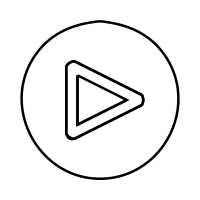

In [4]:
print(sample_1)
display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [5]:
def clean_svg(svg_text):
    # 1. Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # 2. Function to clean ONLY the path data string
    def clean_path_data(match):
        path_string = match.group(1)

        # Space out the letters (M, L, C, Z, etc.)
        path_string = re.sub(r"([a-zA-Z])", r" \1 ", path_string)

        # Replace commas with spaces
        path_string = path_string.replace(",", " ")

        # Round numbers to 1 decimal place
        def round_match(m):
            try:
                return f"{float(m.group(0)):.1f}"
            except ValueError:
                return m.group(0)

        path_string = re.sub(r"-?\d*\.?\d+", round_match, path_string)

        # Clean up any messy double-spaces inside the quotes
        path_string = re.sub(r"\s+", " ", path_string).strip()

        # Return it wrapped back in d="..."
        return f'd="{path_string}"'

    # 3. Apply the cleaner ONLY to the d="..." attributes
    svg_text = re.sub(r'd="([^"]+)"', clean_path_data, svg_text)

    # 4. Clean up any overall messy whitespace
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text


# Example Test:
raw_svg = '<svg><path d="M10,20.35L.5 30"/></svg>'
print(clean_svg(raw_svg))

<svg><path d="M 10.0 20.4 L 0.5 30.0"/></svg>


In [6]:
svg_string = clean_svg(sample_1)
print(svg_string)

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.0 2.6 L 12.0 2.6 C 13.6 2.7 15.1 3.1 16.4 3.7 C 17.8 4.4 18.9 5.4 19.9 6.8 C 21.2 8.7 21.6 11.0 21.3 13.1 C 21.0 15.2 20.0 17.2 18.5 18.7 C 17.0 20.3 15.0 21.3 12.6 21.4 C 10.0 21.6 7.7 20.7 6.0 19.2 C 4.2 17.7 3.1 15.5 2.7 13.3 C 2.4 11.0 2.8 8.6 4.4 6.4 C 5.3 5.1 6.4 4.2 7.7 3.6 C 9.0 3.0 10.5 2.7 12.0 2.6 L 12.0 2.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 12.6 L 13.0 14.6 L 8.9 16.7 C 8.3 16.8 8.2 16.6 7.9 16.0 L 7.9 12.0 L 8.0 8.0 C 8.1 7.6 8.5 7.4 8.9 7.3 L 8.9 7.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 12.6 L 13.0 14.6 L 8.9 16.7 C 8.5 16.6 8.1 16.4 7.9 16.1 L 7.9 1

### Clean and verify all svgs in training set


In [7]:
TOKEN_THRESHOLD = 2048

In [8]:
from svg_utils import process_row

In [9]:
print("Cleaning datasets with multiprocessing...")
cleaned_dataset = dataset.map(process_row, num_proc=8)
print("Done!")

remaining_items = len(cleaned_dataset)
print(remaining_items)

Cleaning datasets with multiprocessing...
Done!
300000


In [10]:
stop_1 = int(remaining_items * 0.98)
stop_2 = stop_1 + int(remaining_items * 0.01)
stop_3 = stop_2 + int(remaining_items * 0.01)

cleaned_train = cleaned_dataset.select(range(stop_1))
cleaned_val = cleaned_dataset.select(range(stop_1, stop_2))
cleaned_test = cleaned_dataset.select(range(stop_2, stop_3))

In [11]:
cleaned_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 294000
})

In [12]:
cleaned_val

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [13]:
cleaned_test

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [14]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


# valid_render runs very long and hasn't filtered out any svg yet... SKIP!

# def valid_render(d):
#     svg_string = d["Svg"]

#     try:
#         cairosvg.svg2png(bytestring=svg_string.encode("utf-8"))
#     except:
#         return False

#     return True


filtered_train = cleaned_train.filter(is_valid)
# filtered_train = filtered_train.filter(valid_render)

In [15]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 204630


## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [16]:
# small initials

VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [17]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [18]:
try:
    tokenizer = Tokenizer.from_file("tokenizer.json")
except:
    print("No tokenizer found in root!")

    tokenizer = Tokenizer(models.BPE())

    tokenizer.pre_tokenizer = pre_tokenizers.Sequence(
        [pre_tokenizers.WhitespaceSplit(), pre_tokenizers.Punctuation()]
    )

    trainer = trainers.BpeTrainer(
        special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
    )

    tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

    tokenizer.save("tokenizer.json")

In [19]:
sample_2 = filtered_train["Svg"][0]
sample_2

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 19.0 7.7 L 22.3 7.7 C 22.4 7.8 22.6 8.0 22.8 8.2 L 22.8 11.7 C 22.6 11.8 22.4 12.0 22.3 12.2 L 19.0 12.2 C 18.8 12.0 18.7 11.8 18.5 11.7 L 18.5 8.2 C 18.7 8.0 18.8 7.8 19.0 7.7 L 19.0 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.9 7.7 L 5.2 7.7 C 5.4 7.8 5.6 8.0 5.7 8.2 L 5.7 11.7 C 5.6 11.8 5.4 12.0 5.2 12.2 L 1.9 12.2 C 1.8 12.0 1.6 11.8 1.5 11.7 L 1.5 8.2 C 1.6 8.0 1.8 7.8 1.9 7.7 L 1.9 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.2 12.1 L 9.5 12.1 C 9.7 12.3 9.8 12.4 10.0 12.6 L 10.0 16.1 C 9.8 16.3 9.7 16.4 9.5 16.6 L 6.2 16.6 C 6.1 16.4 5.9 16.3 5.8 16.1 L 5.8 12.6 C 5.9 12.4 6.1 12.3 6.2 12.1 L 6.2 12.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1

In [20]:
encoded_sample_2 = tokenizer.encode(sample_2)

print(encoded_sample_2)


# First 10 tokens on encoding
for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
    print(f"{id} -> {token}")

Encoding(num_tokens=694, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
17 -> <
90 -> svg
116 -> xmlns
18 -> =
2 -> "
110 -> http
16 -> :
5 -> /
5 -> /
111 -> www


In [21]:
tokenizer.decode(encoded_sample_2.ids)

'< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 19 . 0 7 . 7 L 22 . 3 7 . 7 C 22 . 4 7 . 8 22 . 6 8 . 0 22 . 8 8 . 2 L 22 . 8 11 . 7 C 22 . 6 11 . 8 22 . 4 12 . 0 22 . 3 12 . 2 L 19 . 0 12 . 2 C 18 . 8 12 . 0 18 . 7 11 . 8 18 . 5 11 . 7 L 18 . 5 8 . 2 C 18 . 7 8 . 0 18 . 8 7 . 8 19 . 0 7 . 7 L 19 . 0 7 . 7 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 1 . 9 7 . 7 L 5 . 2 7 . 7 C 5 . 4 7 . 8 5 . 6 8 . 0 5 . 7 8 . 2 L 5 . 7 11 . 7 C 5 . 6 11 . 8 5 . 4 12 . 0 5 . 2 12 . 2 L 1 . 9 12 . 2 C 1 . 8 12 . 0 1 . 6 11 . 8 1 . 5 11 . 7 L 1 . 5 8 . 2 C 1 . 6 8 . 0 1 . 8 7 . 8 1 . 9 7 . 7 L 1 . 9 7 . 7 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 .

In [22]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [23]:
tokenized_train = filtered_train.map(tokenize_svg)

In [24]:
tokenized_train["input_ids"]

Column([[17, 90, 116, 18, 2, 110, 16, 5, 5, 111, 4, 108, 4, 114, 5, 96, 5, 90, 2, 115, 18, 2, 6, 4, 6, 6, 4, 6, 91, 4, 6, 91, 4, 6, 2, 113, 18, 2, 95, 2, 70, 18, 2, 95, 2, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 67, 4, 6, 13, 4, 13, 22, 72, 4, 9, 13, 4, 13, 21, 72, 4, 10, 13, 4, 14, 72, 4, 12, 14, 4, 6, 72, 4, 14, 14, 4, 8, 22, 72, 4, 14, 62, 4, 13, 21, 72, 4, 12, 62, 4, 14, 72, 4, 10, 53, 4, 6, 72, 4, 9, 53, 4, 8, 22, 67, 4, 6, 53, 4, 8, 21, 66, 4, 14, 53, 4, 6, 66, 4, 13, 62, 4, 14, 66, 4, 11, 62, 4, 13, 22, 66, 4, 11, 14, 4, 8, 21, 66, 4, 13, 14, 4, 6, 66, 4, 14, 13, 4, 14, 67, 4, 6, 13, 4, 13, 22, 67, 4, 6, 13, 4, 13, 2, 19, 17, 5, 58, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 7, 4, 15, 13, 4, 13, 22, 11, 4, 8, 13, 4, 13, 21, 11, 4, 10, 13, 4, 14, 11, 4, 12, 14, 4, 6, 11, 4, 13, 14, 4, 8, 22, 

In [25]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tqdm(tokenized_dataset["input_ids"]):
        concat_arr.extend(arr)

    return concat_arr


train_input_ids = flatten_input_ids(tokenized_train)
train_input_ids = np.array(train_input_ids)

len(train_input_ids)

  0%|          | 0/204630 [00:00<?, ?it/s]

130428077

### Create, clean, filter, and tokenize test/val datasets


In [26]:
filtered_test = cleaned_test.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)
test_input_ids = np.array(test_input_ids)

filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)
val_input_ids = np.array(val_input_ids)

  0%|          | 0/2066 [00:00<?, ?it/s]

  0%|          | 0/2088 [00:00<?, ?it/s]

In [27]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 133084710
Number of tokens in train: 130428077 -> 98.00%
Number of tokens in val: 1355632 -> 1.02%
Number of tokens in test: 1301001 -> 0.98%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


## 2.0 Dataloaders


In [28]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert to 1D tensors
train_data = torch.tensor(train_input_ids, dtype=torch.long)
val_data = torch.tensor(val_input_ids, dtype=torch.long)

# We want sequences of length (BLOCK_SIZE + 1)
# Assuming you still have BLOCK_SIZE = 256 from your earlier cell
seq_len = BLOCK_SIZE + 1


def chunk_data(data, seq_len):
    # Calculate how many full sequences we can make
    num_chunks = len(data) // seq_len

    # Truncate any leftover tokens at the very end that don't fit into a full chunk
    data = data[: num_chunks * seq_len]

    # Reshape the 1D tensor into a 2D grid of shape (num_chunks, seq_len)
    return data.view(num_chunks, seq_len)


# 2. Reshape 1D streams into 2D grids
train_data_2d = chunk_data(train_data, seq_len)
val_data_2d = chunk_data(val_data, seq_len)

# 3. NOW we can slice into X and Y safely!
# X gets everything except the last token of each chunk
X_train = train_data_2d[:, :-1]
# Y gets everything except the first token of each chunk
Y_train = train_data_2d[:, 1:]

X_val = val_data_2d[:, :-1]
Y_val = val_data_2d[:, 1:]

# 4. Bundle into TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"X shape: {X_train.shape}, Y shape: {Y_train.shape}")

X shape: torch.Size([507502, 256]), Y shape: torch.Size([507502, 256])


## 2.1 Model Construction


In [29]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (n_embd)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (C**-0.5)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()

        head_size = d_model // n_heads

        self.heads = nn.ModuleList(
            [Head(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):

        # Runs input through each attention head, and glues them together side-by-side
        x = torch.concat([head(x) for head in self.heads], dim=-1)

        # Mixes the (head_size x n_heads) head outputs back to one d_model dimensional layer
        x = self.proj(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class CustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [30]:
def estimate_loss(model, val_loader, eval_iters=50):

    model.eval()
    with torch.inference_mode():
        losses = torch.zeros(eval_iters)
        val_iter = iter(val_loader)

        for k in range(eval_iters):
            try:
                X, Y = next(val_iter)
            except StopIteration:
                val_iter = iter(val_loader)
                X, Y = next(val_iter)

            X, Y = X.to(device), Y.to(device)

            _, loss = model(X, targets=Y)

            losses[k] = loss.item()

    model.train()
    return losses.mean().item()


def train_loop(
    model, optimizer, train_loader, val_loader, steps, scheduler=None, eval_interval=100
):
    model.train()
    train_iter = iter(train_loader)

    for step in range(steps):
        try:
            X, Y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            X, Y = next(train_iter)

        X, Y = X.to(device), Y.to(device)

        _, loss = model(X, targets=Y)

        optimizer.zero_grad()
        loss.backward()

        # Clipping gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # print(current_lr)

        if step % eval_interval == 0 or step == steps - 1:
            current_lr = optimizer.param_groups[0]["lr"]
            val_loss = estimate_loss(model, val_loader)
            print(
                f"Step {step:04d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | lr: {current_lr:.9e}"
            )

    return estimate_loss(model, val_loader)

## 2.2 Single Burn Run


In [31]:
model = CustomTransformer(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_layers=4,
    n_heads=4,
    d_model=128,
    d_ff=512,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"total_params: {total_params}")

total_params: 1081576


In [32]:
model.eval()

with torch.inference_mode():

    # start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
    start_context = tokenizer.encode("<svg ").ids
    # print(start_context)
    start_point = torch.tensor([start_context], device=device)

    print(start_point)
    print(start_point.shape)

    result = model.generate(start_point, 100)
    print(result.shape)
    result = result.squeeze(0).cpu().tolist()
    result.append(0)

    print(result)

    decoded = tokenizer.decode(result)

    print(decoded)

tensor([[17, 90]], device='cuda:0')
torch.Size([1, 2])
torch.Size([1, 102])
[17, 90, 679, 611, 762, 829, 169, 235, 761, 571, 143, 77, 233, 335, 356, 179, 988, 130, 351, 289, 91, 410, 885, 852, 871, 637, 617, 521, 288, 149, 649, 791, 654, 463, 19, 593, 878, 481, 888, 878, 40, 377, 237, 231, 899, 190, 673, 652, 719, 495, 551, 972, 764, 946, 864, 803, 929, 138, 827, 687, 305, 302, 888, 463, 3, 723, 197, 493, 147, 58, 430, 92, 967, 406, 201, 789, 745, 601, 932, 734, 753, 187, 136, 639, 76, 984, 95, 566, 604, 130, 193, 403, 429, 903, 428, 911, 675, 18, 874, 194, 447, 228, 0]
< svg 556 723 511 786 87 125 1410 497 42 ne 116 249 262 140 936 38 251 191 24 401 805 702 750 582 606 389 164 56 593 772 1412 394 > 476 686 356 654 686 s 261 134 139 937 95 733 523 703 398 432 957 751 871 931 661 1138 49 773 515 193 162 654 394 - 1417 150 322 59 path 336 ht 993 338 115 1022 563 386 1511 730 560 92 47 1404 in 861 200px 435 527 38 85 304 358 789 331 1143 605 = 1001 97 403 135


In [36]:
optimizer = AdamW(model.parameters())

temp_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
temp_val_loader = DataLoader(val_dataset, batch_size=64)

train_loop(model, optimizer, temp_train_loader, temp_val_loader, steps=1000)

Step 0000 | Train Loss: 7.1426 | Val Loss: 6.6070 | lr: 1.000000000e-03
Step 0100 | Train Loss: 1.8712 | Val Loss: 1.8286 | lr: 1.000000000e-03
Step 0200 | Train Loss: 1.5494 | Val Loss: 1.5169 | lr: 1.000000000e-03
Step 0300 | Train Loss: 1.3924 | Val Loss: 1.3064 | lr: 1.000000000e-03
Step 0400 | Train Loss: 1.1692 | Val Loss: 1.1721 | lr: 1.000000000e-03
Step 0500 | Train Loss: 1.1043 | Val Loss: 1.1271 | lr: 1.000000000e-03
Step 0600 | Train Loss: 1.0230 | Val Loss: 1.0736 | lr: 1.000000000e-03
Step 0700 | Train Loss: 0.9745 | Val Loss: 1.0222 | lr: 1.000000000e-03
Step 0800 | Train Loss: 0.9053 | Val Loss: 0.9713 | lr: 1.000000000e-03
Step 0900 | Train Loss: 0.9863 | Val Loss: 0.9435 | lr: 1.000000000e-03
Step 0999 | Train Loss: 0.8863 | Val Loss: 0.9237 | lr: 1.000000000e-03


0.9236642718315125

In [42]:
model.eval()

with torch.inference_mode():

    # start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
    start_context = tokenizer.encode("<svg ").ids
    # print(start_context)
    start_point = torch.tensor([start_context], device=device)

    print(start_point)
    print(start_point.shape)

    result = model.generate(start_point, 1000)
    print(result.shape)
    result = result.squeeze(0).cpu().tolist()
    result.append(0)

    print(result)

    decoded = tokenizer.decode(result)

    print(decoded)

tensor([[17, 90]], device='cuda:0')
torch.Size([1, 2])
torch.Size([1, 1002])
[17, 90, 116, 18, 2, 110, 16, 5, 5, 111, 4, 108, 4, 6, 91, 4, 114, 5, 96, 5, 90, 2, 115, 18, 2, 6, 4, 6, 6, 4, 6, 91, 4, 6, 91, 4, 6, 2, 113, 18, 2, 95, 2, 70, 18, 2, 95, 2, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 15, 4, 15, 10, 4, 12, 22, 15, 4, 9, 15, 4, 14, 21, 15, 4, 12, 11, 4, 10, 62, 4, 15, 11, 4, 10, 63, 4, 14, 10, 4, 6, 22, 63, 4, 9, 11, 4, 14, 22, 66, 4, 14, 10, 4, 10, 22, 66, 4, 14, 10, 4, 10, 22, 71, 4, 14, 8, 4, 10, 21, 72, 4, 6, 10, 4, 9, 71, 4, 12, 9, 4, 9, 72, 4, 8, 10, 4, 14, 22, 72, 4, 14, 14, 4, 14, 21, 72, 4, 13, 15, 4, 6, 72, 4, 14, 13, 4, 10, 72, 4, 14, 14, 4, 14, 21, 72, 4, 7, 15, 4, 14, 72, 4, 14, 55, 4, 11, 72, 4, 15, 53, 4, 15, 22, 72, 4, 14, 60, 4, 11, 21, 72, 4, 10, 64, 4, 10, 71, 4, 11, 54, 4, 10, 54, 4, 15, 54, 4, 8, 21, 65, 4, 11, 54, 4, 8, 65, 4, 11, 65, 4, 10, 67, 4, 8, 65, 4, 14, 22

--- Extracted and Cleaned SVG ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="200" height="200">
    <path fill="none" stroke="black" stroke-width="0.5" d=" M 9.9 4.6 L 9.3 9.8 C 9.6 5.4 11.9 5.4 13.8 4.0 L 13.3 5.8 L 18.8 4.4 L 18.8 4.4 L 21.8 2.4 C 22.0 4.3 21.6 3.3 22.2 4.8 L 22.8 8.8 C 22.7 9.0 22.8 7.4 22.8 8.8 C 22.1 9.8 22.8 10.5 22.9 12.9 L 22.8 14.5 C 22.4 16.4 21.5 20.4 20.9 20.2 C 17.5 20.2 17.5 17.4 19.2 17.8 L 19.2 15.0 C 18.0 19.3 17.2 17.8 16.5 16.7 C 15.4 17.5 12.7 17.6 12.6 19.7 C 10.9 18.9 10.8 18.8 14.5 12.4 C 14.9 16.8 13.9 17.0 14.8 14.4 L 15.6 14.7 L 16.6 14.8 C 15.0 15.1 14.8 14.3 14.8 13.7 C 14.3 14.8 14.2 14.6 13.3 14.9 C 13.4 14.8 9.3 15.9 8.0 C 14.6 9.1 14.7 8.9 14.1 8.0 C 9.1 9.3 9.9 10.0 9.4 9.0 C 8.5 10.9 8.2 8.2 12.2 8.7 C 12.9 8.0 8.9 12.0 9.8.0 L 12.0 9.6 C 10.7 8.6 12.8 10.3 6.8 12.9 C 6.3 12.0 7.2 11.1 10.8 7.2 C 8.2 9.7 9.0 9.8 9.7 9.7 C 8.7 9.4 9.4 8.0 9.1 9.1 L 9.1 9.1 C 10.2 7.3 12.5 9.2 12.8 3.0 L 10.0 3.3 C 10.3 2.3 12.8 2

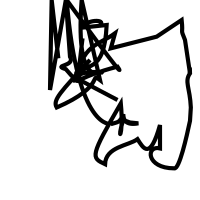

In [44]:
# Extract all the 'd' (path data) strings from the model's output
# This regex looks for d=" followed by anything that isn't a quote
path_strings = re.findall(r'd\s*=\s*"([^"]+)"', decoded)

clean_paths = []
for path_data in path_strings:
    # Clean up tokenizer spaces around dots and numbers (e.g., "1 . 0" -> "1.0")
    clean_data = re.sub(r"\s*\.\s*", ".", path_data)

    # Wrap it in a perfectly formatted path tag
    clean_paths.append(
        f'<path fill="none" stroke="black" stroke-width="0.5" d="{clean_data}" />'
    )

# 2. Inject the paths into a clean, hardcoded SVG shell
final_svg = f"""<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="200" height="200">
    {''.join(clean_paths)}
</svg>"""

print("--- Extracted and Cleaned SVG ---")
print(final_svg)
print("\n--- Rendered Image ---")

try:
    display(SVG(final_svg))
except Exception as e:
    print(f"Failed to render: {e}")

## 2.3 LR Sweep


In [46]:
# Straight from the assignment pdf
configs = {
    "Tiny": {"d_model": 128, "n_layers": 4, "n_heads": 4, "d_ff": 512},
    # "Small": {"d_model": 192, "n_layers": 6, "n_heads": 6, "d_ff": 768},
    # "Medium": {"d_model": 384, "n_layers": 6, "n_heads": 6, "d_ff": 1536},
    # "Large": {"d_model": 512, "n_layers": 10, "n_heads": 7, "d_ff": 2048},
    # "XL": {"d_model": 768, "n_layers": 12, "n_heads": 12, "d_ff": 3072},
}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


results = {}
fixed_training_steps = 2000

In [47]:
lrs = np.logspace(-7, -1, num=7)
print(lrs)

[1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01]


In [48]:
lr_results = []
sweep_steps = 1000

print("Starting Learning Rate Sweep on Tiny Model...")

for lr in lrs:
    print(f"\n--- Testing LR: {lr:.1e} ---")

    # 1. RE-INITIALIZE THE MODEL inside the loop so it starts fresh!
    sweep_model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=TOKEN_THRESHOLD, **configs["Tiny"]
    ).to(device)

    # 2. Initialize the optimizer with the current LR
    optimizer = AdamW(sweep_model.parameters(), lr=lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=100,  # e.g., 100 warmup steps
        max_epochs=sweep_steps,  # Total training steps
        warmup_start_lr=0.0,  # Warmup starts at 0.0
        eta_min=lr * 0.1,  # Cosine decays down to 10% of max LR
    )

    # 3. Train the model
    # (Replace `train_loop` with whatever your actual training function/loop is called)
    val_loss = train_loop(
        sweep_model,
        optimizer,
        train_loader,
        val_loader,
        steps=sweep_steps,
        scheduler=scheduler,
    )

    # For demonstration, assign your actual returned val_loss here
    # val_loss = 0.0

    lr_results.append(val_loss)
    print(f"Final Val Loss for LR {lr:.1e}: {val_loss:.4f}")

Starting Learning Rate Sweep on Tiny Model...

--- Testing LR: 1.0e-07 ---


C:\Users\Vince\AppData\Local\Temp\ipykernel_25956\388978128.py:17: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.0235 | Val Loss: 7.0264 | lr: 1.010101010e-09


KeyboardInterrupt: 

In [50]:
best_lr = 1e-2
print(f"Lowest val_loss when lr = {best_lr}")

Lowest val_loss when lr = 0.01


## 2.4 Train Model Family


In [51]:
scaling_results = {}

steps_per_epoch = len(train_loader)
print(
    f"Starting Scaling Laws Experiment with Best LR = {best_lr} (1 Epoch = {steps_per_epoch} steps)"
)

for name, config in configs.items():
    print(f"\\n{'='*40}")
    print(f"Training {name} Model")
    print(f"{'='*40}")

    # Initialize the model with the specific config
    model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=TOKEN_THRESHOLD, **config
    ).to(device)

    params = count_parameters(model)
    print(f"Parameters: {params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(steps_per_epoch * 0.1),
        max_epochs=steps_per_epoch,
        warmup_start_lr=0.0,
        eta_min=best_lr * 0.1,  # Decay to 10% of max LR
    )

    final_val_loss = train_loop(
        model,
        optimizer,
        train_loader,
        val_loader,
        steps=steps_per_epoch,
        scheduler=scheduler,
        eval_interval=200,
    )

    scaling_results[name] = {"params": params, "val_loss": final_val_loss}

    print(f"✅ {name} finished! Final Val Loss: {final_val_loss:.4f}")

    # Optional: Save the model weights so you can generate SVGs later
    torch.save(model.state_dict(), f"model_{name.lower()}.pt")

Starting Scaling Laws Experiment with Best LR = 0.01 (1 Epoch = 7930 steps)
\n========================================
Training Tiny Model
Parameters: 1,310,952


C:\Users\Vince\AppData\Local\Temp\ipykernel_25956\208821421.py:23: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.1490 | Val Loss: 7.1459 | lr: 1.262626263e-05
Step 0200 | Train Loss: 1.4806 | Val Loss: 1.5352 | lr: 2.537878788e-03
Step 0400 | Train Loss: 1.0968 | Val Loss: 1.0471 | lr: 5.063131313e-03
Step 0600 | Train Loss: 0.8924 | Val Loss: 0.8540 | lr: 7.588383838e-03
Step 0800 | Train Loss: 0.8091 | Val Loss: 0.8021 | lr: 9.999972098e-03
Step 1000 | Train Loss: 0.8029 | Val Loss: 0.8431 | lr: 9.981151616e-03
Step 1200 | Train Loss: 0.8336 | Val Loss: 0.7844 | lr: 9.927622503e-03
Step 1400 | Train Loss: 0.7387 | Val Loss: 0.7415 | lr: 9.839799370e-03
Step 1600 | Train Loss: 0.6798 | Val Loss: 0.7053 | lr: 9.718362447e-03
Step 1800 | Train Loss: 0.6994 | Val Loss: 0.6798 | lr: 9.564252321e-03
Step 2000 | Train Loss: 0.6908 | Val Loss: 0.6608 | lr: 9.378662646e-03
Step 2200 | Train Loss: 0.6668 | Val Loss: 0.6482 | lr: 9.163030903e-03
Step 2400 | Train Loss: 0.6520 | Val Loss: 0.6380 | lr: 8.919027260e-03
Step 2600 | Train Loss: 0.6215 | Val Loss: 0.6245 | lr: 8.648541

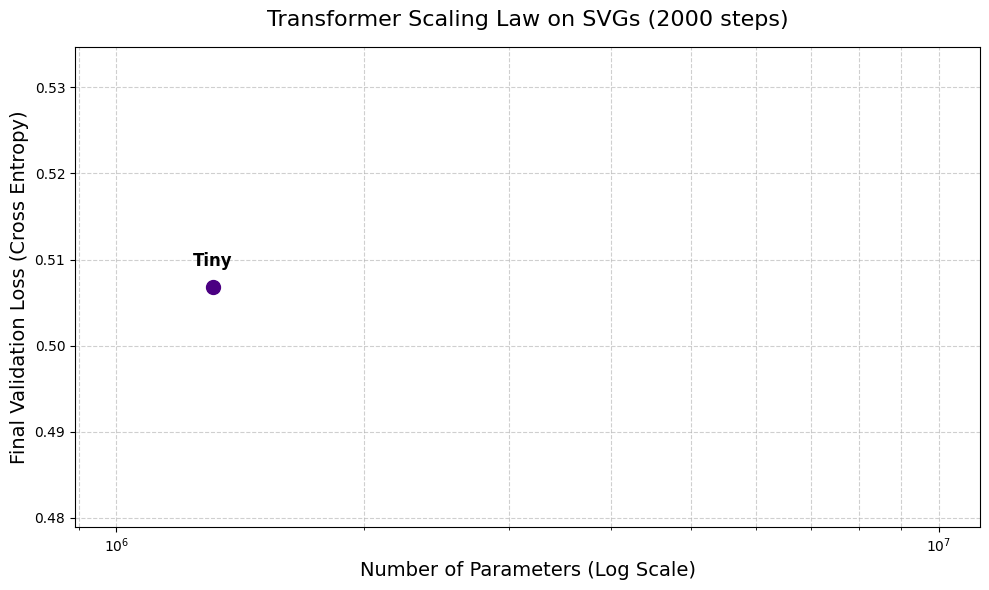

In [52]:
# ==========================================
# Plotting the Scaling Law
# ==========================================
params_list = [res["params"] for res in scaling_results.values()]
losses_list = [res["val_loss"] for res in scaling_results.values()]
labels = list(scaling_results.keys())

plt.figure(figsize=(10, 6))

# Plot Param count vs Loss
plt.plot(
    params_list,
    losses_list,
    marker="o",
    linestyle="-",
    linewidth=2.5,
    markersize=10,
    color="indigo",
)

# CRITICAL: The X-axis must be log scale to see the power law
plt.xscale("log")

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (params_list[i], losses_list[i]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

plt.title(
    f"Transformer Scaling Law on SVGs ({fixed_training_steps} steps)",
    fontsize=16,
    pad=15,
)
plt.xlabel("Number of Parameters (Log Scale)", fontsize=14)
plt.ylabel("Final Validation Loss (Cross Entropy)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.6)

plt.tight_layout()
plt.show()